# Plot Initial Conditions from `.inp` Files

This notebook loads BRNS initial condition files (`*.inp`) from a model directory (for example `models/equilibrium`) and plots them.

It uses compact, reusable helper methods from `notebooks.utils.inp_initial_conditions`.

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt

from notebooks.utils.inp_initial_conditions import (
    collect_inp_datasets,
    summarize_inp_datasets,
    plot_inp_profiles,
    plot_single_inp_profile,
)

%matplotlib inline

In [ ]:
# ----------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------
# Notebook location: BRNSPackage/notebooks
# Example model directory: BRNSPackage/models/equilibrium
import warnings

MODEL_DIR = (Path('..') / "BRNSPackage" / 'models' / 'equilibrium').resolve()

print('Model directory:', MODEL_DIR)
print('Exists:', MODEL_DIR.exists())

if not MODEL_DIR.exists():
    warnings.warn(f"Model directory not found: {MODEL_DIR}. No datasets will be loaded.")

datasets = collect_inp_datasets(MODEL_DIR)
print(f'Loaded .inp files: {len(datasets)}')
if len(datasets) == 0:
    warnings.warn("No .inp files were loaded; later plotting cells will have nothing to show.")
print('Files:')
for name in sorted(datasets.keys()):
    print(f'  - {name}')


Model directory: /mnt/c/Tecklenburg.J/work/thermooptiplan/BRNSPackage/models/equilibrium
Exists: True
Loaded .inp files: 18
Files:
  - ch2o.inp
  - co2.inp
  - co3.inp
  - fe2.inp
  - feco3.inp
  - feoh3.inp
  - fes.inp
  - h2s.inp
  - hco3.inp
  - hplus.inp
  - hs.inp
  - mn2.inp
  - mnco3.inp
  - mno2.inp
  - nh4.inp
  - no3.inp
  - o2.inp
  - so4.inp


In [7]:
# Compact summary table
summary = summarize_inp_datasets(datasets)

print('Summary (first 10 rows):')
for row in summary[:10]:
    print(
        f"{row['file']:12} | rows={row['rows']:4d} | "
        f"value=[{row['value_min']:.3e}, {row['value_max']:.3e}] | "
        f"depth=[{row['depth_min']:.2f}, {row['depth_max']:.2f}]"
    )

Summary (first 10 rows):
ch2o.inp     | rows= 111 | value=[1.027e-07, 2.001e-03] | depth=[0.00, 50.00]
co2.inp      | rows= 111 | value=[2.119e-05, 2.668e-04] | depth=[0.00, 50.00]
co3.inp      | rows= 111 | value=[2.779e-05, 1.287e-04] | depth=[0.00, 50.00]
fe2.inp      | rows= 111 | value=[1.000e-15, 1.145e-04] | depth=[0.00, 50.00]
feco3.inp    | rows= 111 | value=[1.000e-20, 1.313e-08] | depth=[0.00, 50.00]
feoh3.inp    | rows= 111 | value=[1.193e-16, 5.810e-05] | depth=[0.00, 50.00]
fes.inp      | rows= 111 | value=[1.000e-20, 1.917e-06] | depth=[0.00, 50.00]
h2s.inp      | rows= 111 | value=[1.000e-15, 7.197e-07] | depth=[0.00, 50.00]
hco3.inp     | rows= 111 | value=[2.143e-03, 3.966e-03] | depth=[0.00, 50.00]
hplus.inp    | rows= 111 | value=[7.943e-09, 5.402e-08] | depth=[0.00, 50.00]


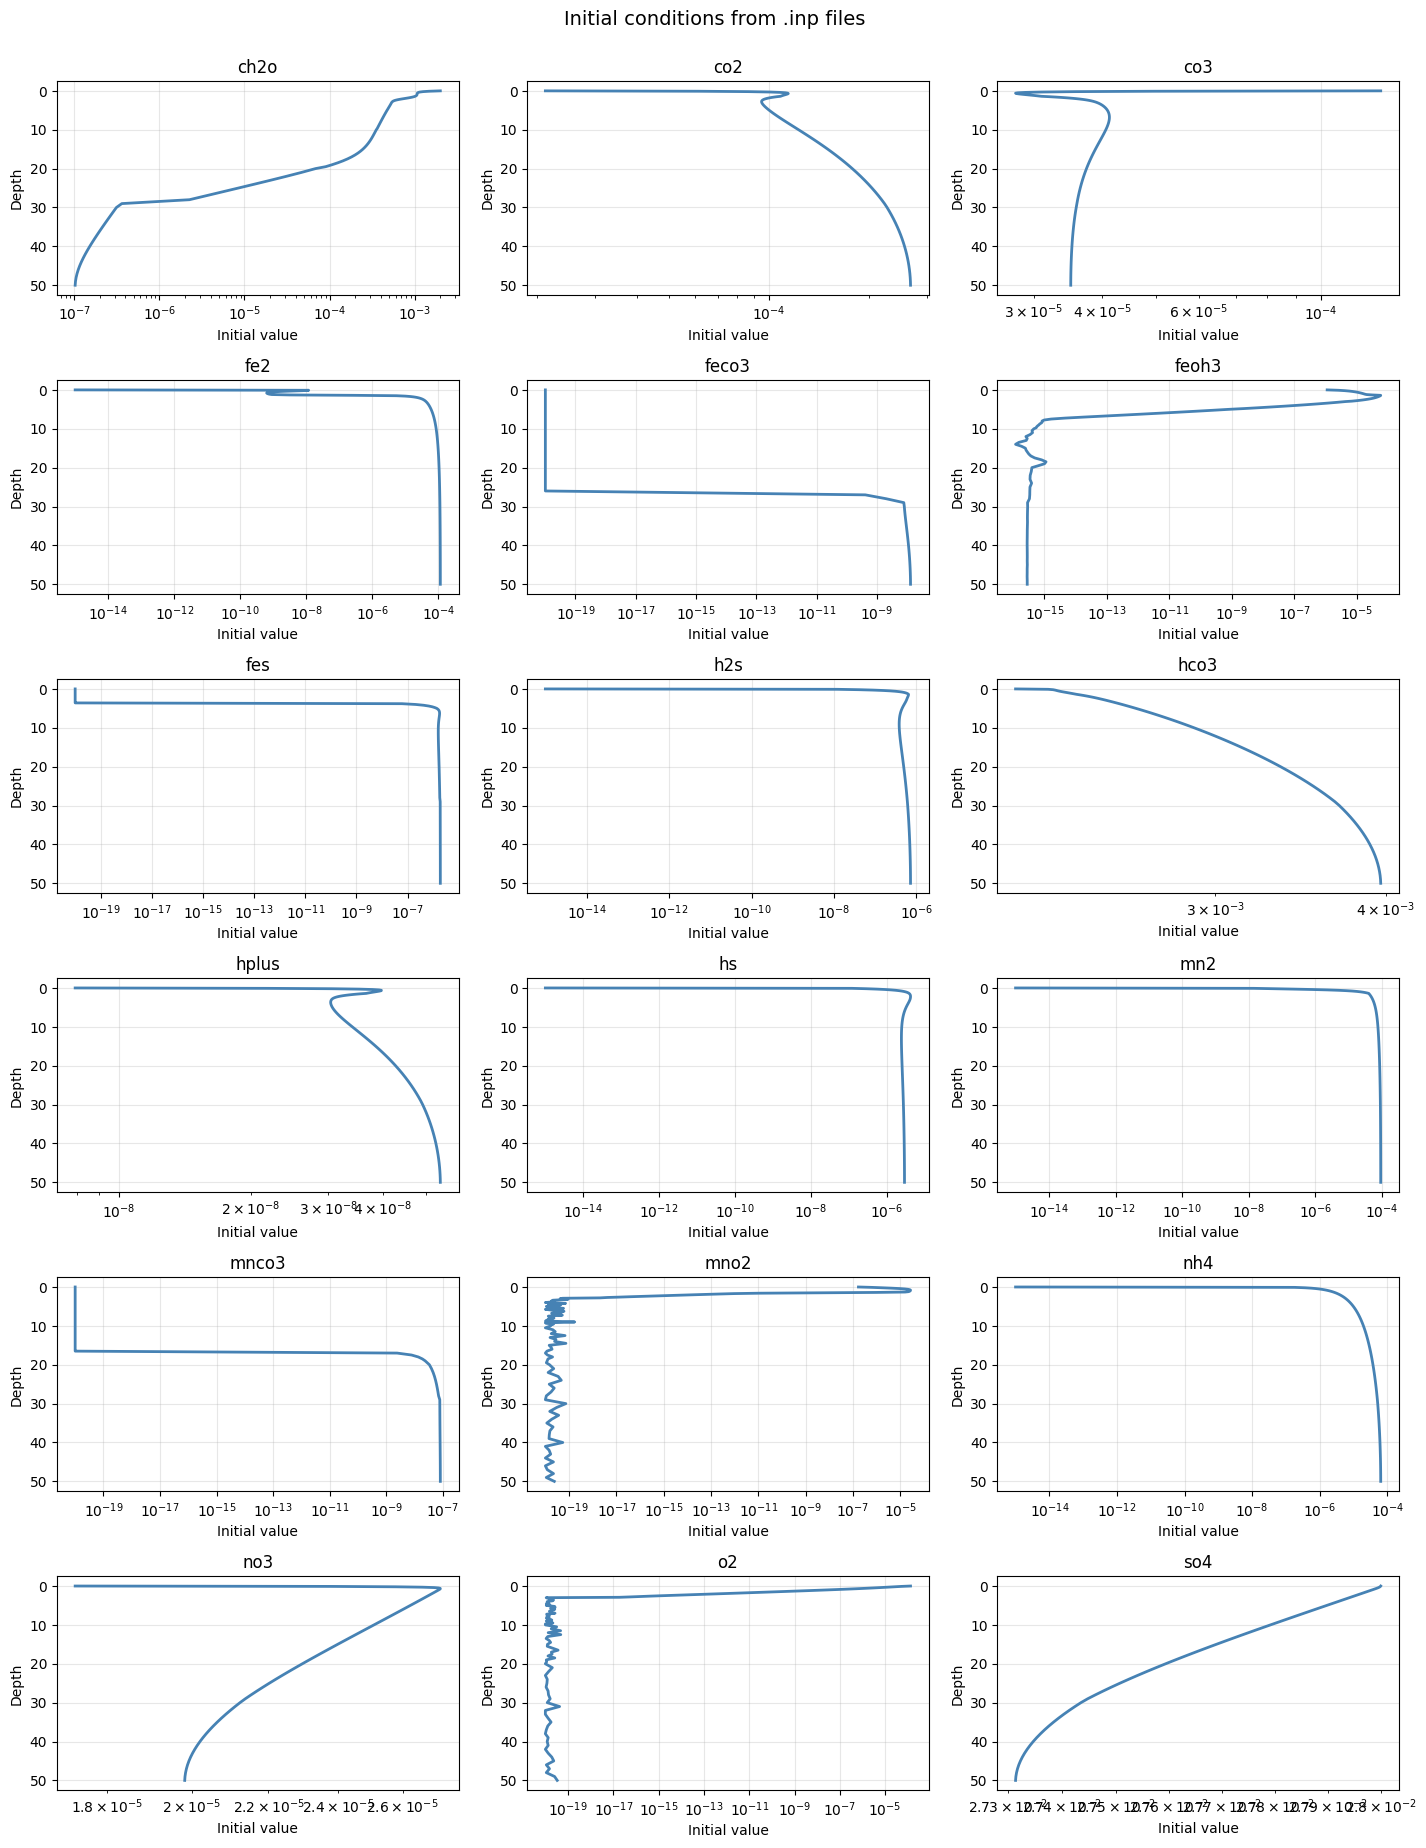

In [ ]:
# Plot all initial profiles in a compact grid
if datasets:
    fig, axes = plot_inp_profiles(
        datasets,
        ncols=3,
        xscale='log',
        invert_depth_axis=True,
    )
    plt.show()
else:
    warnings.warn("No datasets available to plot.")


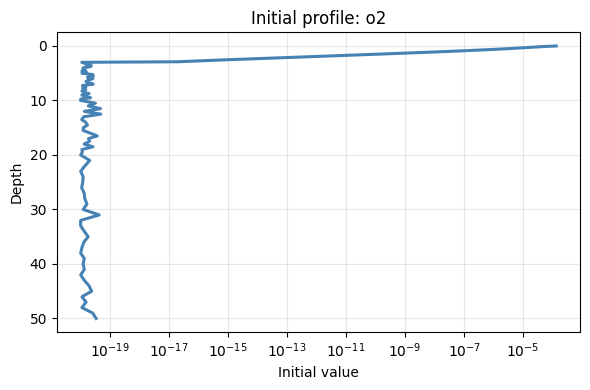

In [ ]:
# Optional: inspect one selected species/profile
SELECTED_FILE = 'o2.inp'  # adjust as needed

if SELECTED_FILE in datasets:
    fig, ax = plt.subplots(figsize=(6, 4))
    plot_single_inp_profile(
        datasets,
        filename=SELECTED_FILE,
        ax=ax,
        xscale='log',
        invert_depth_axis=True,
    )
    plt.tight_layout()
    plt.show()
else:
    warnings.warn(f"'{SELECTED_FILE}' not found among loaded datasets; skipping single-profile plot.")
